# 06. 도구 연동 (Tools Integration)

> 에이전트의 핵심은 **언제 어떤 도구를 호출할지** LLM이 직접 결정하는 것이에요. `@tool`, `bind_tools`, `ToolNode`, `tools_condition` 으로 챗봇 ↔ 도구 루프를 만드는 부품을 모두 다룹니다.

## 학습 목표

이 노트북을 마치면 다음을 할 수 있어요:

1. `@tool` 데코레이터로 Python 함수를 LLM이 호출할 수 있는 도구(Tool)로 변환할 수 있어요
2. `llm.bind_tools(tools)`로 LLM에 도구를 바인딩하고, `tool_calls`가 포함된 AIMessage 구조를 이해할 수 있어요
3. `BasicToolNode`를 직접 구현해서 도구 실행 노드의 내부 동작을 이해하고, `ToolNode`(사전 구축 컴포넌트)와 차이를 설명할 수 있어요
4. `tools_condition`과 `add_conditional_edges`로 챗봇 ↔ 도구 루프를 가진 에이전트 그래프를 구성할 수 있어요
5. `handle_tool_errors` 옵션으로 도구 실행 중 발생하는 에러를 처리할 수 있어요

## 사전 지식

- 이전 노트북 `05-ChatBot.ipynb`에서 배운 StateGraph, State, add_messages 개념
- LangGraph의 Node와 Edge 추가 방법 (`add_node`, `add_edge`)
- Python 데코레이터 기본 이해

## 도구 연동 에이전트의 구조

이전 노트북에서 만든 챗봇은 LLM이 학습한 지식만 활용할 수 있었어요. 하지만 실제 에이전트는 웹 검색, 계산기, 데이터베이스 조회 같은 **외부 도구(Tool)**를 호출해서 실시간 정보를 가져올 수 있어야 해요.

도구 연동의 핵심은 **조건부 루프(Conditional Loop)**예요. 이것은 마치 **도서관 사서**와 같아요. 질문을 받으면 머릿속 지식으로 바로 답할 수도 있지만, 정확한 정보가 필요하면 책(도구)을 찾아보고, 찾은 내용을 바탕으로 답변을 완성해요. 한 권으로 부족하면 다른 책도 참고하죠. 이 "판단 -> 조사 -> 답변" 반복이 에이전트의 핵심 루프예요. LLM이 도구 호출이 필요하다고 판단하면 도구를 실행하고 결과를 다시 LLM에 전달해요. 충분한 정보가 모이면 루프에서 벗어나 최종 답변을 생성하죠.

> 🔑 **핵심 개념**: 에이전트의 핵심은 **LLM이 다음 행동을 스스로 결정**한다는 거예요. `tool_calls`가 있으면 도구를 실행하고, 없으면 최종 답변을 생성해요. LangGraph는 이 루프를 그래프 구조로 표현해요.

### 전체 아키텍처

```mermaid
flowchart TD
    U(["사용자 입력<br>User Input"]) --> S(["__start__"])
    S --> C["chatbot 노드<br>LLM + bind_tools"]
    C -- "tool_calls 있음" --> T["tools 노드<br>ToolNode 실행"]
    C -- "tool_calls 없음" --> E(["__end__"])
    T -- "ToolMessage 반환" --> C
    E --> R(["최종 응답<br>Final Answer"])

    classDef input fill:#d4edda,stroke:#28a745,color:#155724
    classDef process fill:#cce5ff,stroke:#007bff,color:#004085
    classDef tools fill:#e2d5f1,stroke:#6f42c1,color:#3d1f6e
    classDef output fill:#fff3cd,stroke:#ffc107,color:#856404

    class U,S input
    class C process
    class T tools
    class E,R output
```

### 핵심 구성 요소

| 구성 요소 | 역할 | 핵심 API |
|-----------|------|----------|
| **@tool 데코레이터** | Python 함수 → LLM 호출 가능 도구로 변환 | `from langchain.tools import tool` |
| **bind_tools** | LLM에 사용 가능한 도구 목록 등록 | `llm.bind_tools(tools)` |
| **ToolNode** | tool_calls 기반으로 도구를 자동 실행하는 노드 | `from langgraph.prebuilt import ToolNode` |
| **tools_condition** | tool_calls 유무로 다음 노드를 결정하는 함수 | `from langgraph.prebuilt import tools_condition` |
| **add_conditional_edges** | 조건 함수 결과에 따라 분기 엣지 추가 | `graph_builder.add_conditional_edges(...)` |

### 메시지 흐름

```mermaid
sequenceDiagram
    participant U as 사용자
    participant C as chatbot 노드
    participant T as tools 노드

    U->>C: HumanMessage("오늘 날씨는?")
    C->>C: LLM 판단: 도구 필요
    C->>T: AIMessage(tool_calls=[search])
    T->>T: search 도구 실행
    T->>C: ToolMessage(결과)
    C->>C: LLM 판단: 충분한 정보
    C->>U: AIMessage(최종 답변)
```

## 환경 설정

In [1]:
# API 키를 환경변수로 관리하기 위한 설정
from dotenv import load_dotenv

# .env 파일에서 API 키 로드
load_dotenv(override=True)

True

In [2]:
# LangSmith 추적 설정 (선택사항 - 실행 흐름을 LangSmith에서 시각화할 수 있어요)
import os

# LangSmith 추적 활성화: 에이전트의 도구 호출 흐름을 시각적으로 디버깅할 수 있어요
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
# os.environ["LANGCHAIN_PROJECT"] = "LangGraph-V1-Tutorial-05-Tools"

## 1. @tool 데코레이터로 도구 정의하기

LangChain에서 도구(Tool)를 만드는 가장 쉬운 방법은 `@tool` 데코레이터예요. Python 함수에 데코레이터를 붙이면 LLM이 호출할 수 있는 도구로 자동 변환돼요.

> 🔑 **핵심 개념**: `@tool` 데코레이터에서 **docstring이 매우 중요**해요. LLM은 docstring을 읽고 이 도구가 무엇을 하는지, 언제 사용해야 하는지 판단해요. docstring이 없거나 불명확하면 LLM이 도구를 잘못 사용할 수 있어요.

> 💡 **실무 팁**: 도구 이름과 파라미터 이름도 LLM의 판단에 영향을 줘요. `search_news(query: str)`처럼 의미가 명확한 이름을 사용하면 LLM이 올바른 파라미터를 전달할 가능성이 높아져요.

In [3]:
# LangChain V1 도구 데코레이터 가져오기
from langchain.tools import tool


# ---------------------------------------------------
# 도구 정의: @tool 데코레이터로 Python 함수를 도구로 변환해요
# ---------------------------------------------------
@tool
def multiply(a: int, b: int) -> int:
    """두 정수를 곱해서 반환해요.

    곱셈 계산이 필요할 때 이 도구를 사용하세요.
    """
    return a * b  # 두 수의 곱셈 결과 반환


@tool
def add(a: int, b: int) -> int:
    """두 정수를 더해서 반환해요.

    덧셈 계산이 필요할 때 이 도구를 사용하세요.
    """
    return a + b  # 두 수의 덧셈 결과 반환


@tool
def get_weather(city: str) -> str:
    """지정한 도시의 현재 날씨 정보를 반환해요.

    날씨 정보가 필요할 때 이 도구를 사용하세요.
    Args:
        city: 날씨를 조회할 도시 이름 (한글 또는 영어)
    """
    # 실제 날씨 API 대신 간단한 더미 응답 반환 (교육용 예제)
    weather_data = {
        "서울": "맑음, 기온 18°C, 습도 55%",
        "부산": "흐림, 기온 21°C, 습도 70%",
        "제주": "비, 기온 23°C, 습도 85%",
    }
    # 등록된 도시면 날씨 반환, 없으면 기본 메시지
    return weather_data.get(city, f"{city}의 날씨 정보를 찾을 수 없어요. 서울, 부산, 제주 중 하나를 입력해주세요.")


# 도구 목록 구성
tools = [multiply, add, get_weather]

# 도구 정의 완료!
print(f"등록된 도구 수: {len(tools)}개")
for t in tools:
    print(f"  - {t.name}: {t.description[:50]}...")

등록된 도구 수: 3개
  - multiply: 두 정수를 곱해서 반환해요.

곱셈 계산이 필요할 때 이 도구를 사용하세요....
  - add: 두 정수를 더해서 반환해요.

덧셈 계산이 필요할 때 이 도구를 사용하세요....
  - get_weather: 지정한 도시의 현재 날씨 정보를 반환해요.

날씨 정보가 필요할 때 이 도구를 사용하세요....


### 도구의 스키마 확인

`@tool` 데코레이터는 함수 시그니처와 docstring을 분석해서 LLM에 전달할 JSON 스키마를 자동으로 생성해요. LLM은 이 스키마를 보고 도구 호출 방법을 파악하죠.

> 🎯 **강의 포인트**: 아래 스키마 출력을 학생들에게 보여주세요. LLM이 실제로 받는 도구 정보가 이런 형태라는 걸 이해하면, `@tool` 데코레이터의 중요성을 직관적으로 알 수 있어요.

In [4]:
import json

# ---------------------------------------------------
# 도구 스키마 확인: LLM에게 전달되는 도구 정보
# ---------------------------------------------------
# === multiply 도구의 스키마 ===
# args_schema: 파라미터 타입 정보를 담은 Pydantic 모델
schema = multiply.args_schema.model_json_schema()
print(json.dumps(schema, indent=2, ensure_ascii=False))

# === get_weather 도구의 스키마 ===
schema = get_weather.args_schema.model_json_schema()
print(json.dumps(schema, indent=2, ensure_ascii=False))

{
  "description": "두 정수를 곱해서 반환해요.\n\n곱셈 계산이 필요할 때 이 도구를 사용하세요.",
  "properties": {
    "a": {
      "title": "A",
      "type": "integer"
    },
    "b": {
      "title": "B",
      "type": "integer"
    }
  },
  "required": [
    "a",
    "b"
  ],
  "title": "multiply",
  "type": "object"
}
{
  "description": "지정한 도시의 현재 날씨 정보를 반환해요.\n\n날씨 정보가 필요할 때 이 도구를 사용하세요.\nArgs:\n    city: 날씨를 조회할 도시 이름 (한글 또는 영어)",
  "properties": {
    "city": {
      "title": "City",
      "type": "string"
    }
  },
  "required": [
    "city"
  ],
  "title": "get_weather",
  "type": "object"
}


## 2. LLM에 도구 바인딩하기 (bind_tools)

`bind_tools()` 메서드로 LLM에 사용 가능한 도구 목록을 등록해요. 도구가 바인딩된 LLM은 사용자 입력을 분석해서 도구 호출이 필요한지 스스로 판단해요.

> 🔑 **핵심 개념**: `bind_tools()`는 LLM에 "이런 도구들을 사용할 수 있어"라고 알려주는 과정이에요. LLM이 도구를 실제로 실행하는 건 아니에요. LLM은 도구 호출 명령(`tool_calls`)을 담은 AIMessage를 반환할 뿐이고, 실제 실행은 별도의 `tools 노드`가 담당해요.

> ⚠️ **자주 하는 실수**: `llm.invoke()`와 `llm_with_tools.invoke()`의 차이를 혼동해요. 도구를 사용하려면 반드시 `bind_tools()` 후 `llm_with_tools`를 사용해야 해요. 일반 `llm`으로는 도구를 호출할 수 없어요.

In [5]:
# LangChain V1 통합 모델 초기화 함수 가져오기
from langchain.chat_models import init_chat_model

# ---------------------------------------------------
# 모델 초기화 및 도구 바인딩
# ---------------------------------------------------
# 기본 모델: gpt-4o-mini (비용 효율적, 도구 호출 지원)
# 다른 모델로 교체할 때: "anthropic:claude-sonnet-4-5"
llm = init_chat_model("openai:gpt-4o-mini")

# bind_tools(): LLM에 사용 가능한 도구 목록 등록
# 이후 LLM은 요청을 분석해서 도구 호출 여부를 스스로 결정해요
llm_with_tools = llm.bind_tools(tools)

# LLM과 도구 바인딩 완료!

In [6]:
# LangChain 메시지 타입 가져오기
from langchain.messages import HumanMessage

# ---------------------------------------------------
# 도구 호출 테스트: LLM이 tool_calls를 포함한 AIMessage를 반환하는지 확인
# ---------------------------------------------------
# 도구 호출이 필요한 질문: 계산이 필요하므로 multiply 도구를 호출할 거예요
test_message = HumanMessage(content="15와 7을 곱하면 얼마예요?")

# llm_with_tools로 메시지 전달
response = llm_with_tools.invoke([test_message])

# === LLM 응답 타입 ===
print(f"응답 클래스: {type(response).__name__}")
print(f"응답 content: '{response.content}'")
print()

# === tool_calls 확인 ===
# tool_calls: LLM이 호출하고 싶은 도구 목록
# 이 정보를 바탕으로 tools 노드가 실제 도구를 실행해요
if response.tool_calls:
    for tc in response.tool_calls:
        print(f"  도구 이름: {tc['name']}")
        print(f"  인자: {tc['args']}")
        print(f"  호출 ID: {tc['id']}")
else:
    #   tool_calls 없음 (LLM이 직접 답변)
    pass

응답 클래스: AIMessage
응답 content: ''

  도구 이름: multiply
  인자: {'a': 15, 'b': 7}
  호출 ID: call_IAdUTNnWeB7nlbYafPUQNbPh


In [7]:
# ---------------------------------------------------
# 비교: 도구가 필요 없는 질문은 tool_calls가 비어있어요
# ---------------------------------------------------
general_message = HumanMessage(content="안녕하세요! 오늘 어떠세요?")
general_response = llm_with_tools.invoke([general_message])

# === 일반 질문 응답 ===
print(f"tool_calls 수: {len(general_response.tool_calls)}개")
# 일반 질문이면 tool_calls가 비어있고 content에 직접 답변이 들어있어요
print(f"content: {general_response.content[:100]}")

tool_calls 수: 0개
content: 안녕하세요! 저는 항상 준비되어 있습니다. 어떻게 도와드릴까요?


## 3. BasicToolNode 직접 구현하기

앞서 `bind_tools()`로 LLM이 **어떤 도구를 호출할지 결정**하는 방법을 배웠어요. 하지만 LLM은 도구를 직접 실행하지 않아요. 누군가가 `tool_calls` 정보를 받아서 실제로 함수를 호출해야 하죠. 그 역할을 하는 것이 **도구 실행 노드**예요.

이 섹션에서는 도구 실행 노드를 **직접 구현**해서 내부 동작을 이해해볼게요. LangGraph가 제공하는 `ToolNode`를 바로 쓰기 전에, 어떻게 작동하는지 먼저 파악하는 거예요.

> 🎯 **강의 포인트**: `BasicToolNode`의 구현 코드를 천천히 설명하세요. "마지막 AIMessage에서 `tool_calls`를 꺼내 → 해당 도구를 찾아 → 실행하고 → `ToolMessage`로 포장"하는 4단계 흐름을 이해하면 LangGraph 도구 실행의 전체 원리를 알 수 있어요.

> 💡 **실무 팁**: 실제 프로젝트에서는 `BasicToolNode` 대신 LangGraph의 내장 `ToolNode`를 사용해요. 에러 처리, 병렬 실행, 상태 주입 등 다양한 고급 기능이 포함되어 있거든요. (이 노트북 후반부에서 다뤄요!)

In [8]:
import json
from langchain.messages import ToolMessage


# ---------------------------------------------------
# BasicToolNode: 도구 실행 노드 직접 구현
# ---------------------------------------------------
class BasicToolNode:
    """AIMessage의 tool_calls를 읽어 도구를 실행하는 간단한 노드예요.

    LangGraph 내장 ToolNode의 기본 동작을 직접 구현해서
    도구 실행 원리를 이해하는 데 사용해요.
    """

    def __init__(self, tools: list) -> None:
        # 도구 이름 → 도구 객체 딕셔너리로 빠르게 조회할 수 있게 해요
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, state: dict) -> dict:
        # STEP 1: 상태에서 메시지 목록을 가져와요
        messages = state.get("messages", [])
        if not messages:
            raise ValueError("메시지가 없어요. tool_calls를 포함한 AIMessage가 필요해요.")

        # STEP 2: 가장 최근 메시지 (AIMessage)를 꺼내요
        ai_message = messages[-1]

        # STEP 3: tool_calls를 순서대로 실행해요
        tool_results = []
        for tool_call in ai_message.tool_calls:
            tool_name = tool_call["name"]      # 호출할 도구 이름
            tool_args = tool_call["args"]       # 도구에 전달할 인자
            tool_call_id = tool_call["id"]      # 호출 ID (매칭용)

            # 도구 이름으로 실제 도구 객체 찾기
            tool_to_run = self.tools_by_name.get(tool_name)
            if tool_to_run is None:
                raise ValueError(f"'{tool_name}' 도구를 찾을 수 없어요.")

            # STEP 4: 도구 실행 후 ToolMessage로 포장해요
            result = tool_to_run.invoke(tool_args)
            tool_results.append(
                ToolMessage(
                    content=str(result),          # 도구 실행 결과 (문자열)
                    name=tool_name,               # 어떤 도구의 결과인지
                    tool_call_id=tool_call_id,    # AIMessage의 tool_call과 매칭
                )
            )

        # 결과 메시지 반환: add_messages 리듀서가 기존 메시지에 추가해줘요
        return {"messages": tool_results}


# BasicToolNode 구현 완료!

In [9]:
from langchain.messages import AIMessage

# ---------------------------------------------------
# BasicToolNode 직접 테스트
# ---------------------------------------------------
# 실제로는 LLM이 생성하지만, 테스트를 위해 수동으로 AIMessage를 만들어요
test_ai_message = AIMessage(
    content="",  # 도구를 호출할 때는 content가 비어있어요
    tool_calls=[
        {
            "name": "multiply",     # 호출할 도구 이름
            "args": {"a": 15, "b": 7},  # 도구 인자
            "id": "test_call_001",  # 고유 호출 ID
            "type": "tool_call",
        }
    ],
)

# BasicToolNode 인스턴스 생성 및 실행
basic_tool_node = BasicToolNode(tools)
result = basic_tool_node({"messages": [test_ai_message]})

# === BasicToolNode 실행 결과 ===
for msg in result["messages"]:
    print(f"메시지 타입: {type(msg).__name__}")
    print(f"도구 이름: {msg.name}")
    print(f"결과: {msg.content}")
    print(f"호출 ID: {msg.tool_call_id}")

메시지 타입: ToolMessage
도구 이름: multiply
결과: 105
호출 ID: test_call_001


## 4. 조건부 엣지 (Conditional Edge)와 에이전트 그래프 구축

도구 노드가 준비되었으니, 이제 챗봇과 도구가 연결된 완전한 에이전트 그래프를 만들어볼게요.

핵심은 **조건부 엣지(Conditional Edge)**예요. 일반 엣지는 항상 같은 노드로 이동하지만, 조건부 엣지는 상태에 따라 다른 노드로 분기해요.

> 🔑 **핵심 개념**: `add_conditional_edges(source, path_function)` 구조를 이해하는 게 중요해요.
> - `source`: 어떤 노드에서 분기할지
> - `path_function`: 현재 상태를 받아 다음 노드 이름(문자열)을 반환하는 함수

> 💡 **실무 팁**: 조건부 엣지 함수를 직접 구현하는 것도 좋지만, LangGraph의 `tools_condition`을 사용하면 코드가 훨씬 간결해져요. `tools_condition`은 마지막 AIMessage에 `tool_calls`가 있으면 `"tools"`, 없으면 `END`를 반환해요.

### 4-1. 라우터 함수 직접 구현 (이해용)

먼저 `tools_condition`이 내부에서 어떻게 동작하는지 이해하기 위해 라우터 함수를 직접 구현해볼게요.

In [ ]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages

# ---------------------------------------------------
# 상태 정의 (이전 챗봇과 동일)
# ---------------------------------------------------
class State(TypedDict):
    # add_messages 리듀서: 메시지를 누적해서 대화 히스토리 유지
    messages: Annotated[list, add_messages]


# ---------------------------------------------------
# 라우터 함수: 도구 호출 여부에 따라 다음 노드 결정
# ---------------------------------------------------
def route_tools(state: State) -> str:
    """챗봇 노드 출력을 검사해서 다음 노드를 결정하는 라우터 함수예요.

    AIMessage에 tool_calls가 있으면 → 'tools' 노드로
    AIMessage에 tool_calls가 없으면 → END로 (그래프 종료)

    이 함수의 역할은 LangGraph 내장 tools_condition과 동일해요.
    """
    messages = state.get("messages", [])
    if not messages:
        raise ValueError(f"메시지가 없어요: {state}")

    # 가장 최근 메시지 (챗봇 노드의 출력 = AIMessage)
    last_message = messages[-1]

    # tool_calls가 있으면 'tools' 노드로 라우팅
    if hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0:
        return "tools"  # tools 노드로 이동

    # tool_calls가 없으면 그래프 종료
    return END


# 라우터 함수 정의 완료!

### 4-2. 에이전트 그래프 구축 (BasicToolNode 사용)

직접 구현한 `BasicToolNode`와 라우터 함수로 에이전트 그래프를 구축해볼게요.

In [11]:
# ---------------------------------------------------
# 챗봇 노드 정의 (도구 바인딩된 LLM 사용)
# ---------------------------------------------------
def chatbot(state: State) -> dict:
    """도구가 바인딩된 LLM으로 메시지를 처리하는 챗봇 노드예요.

    도구 호출이 필요하면 AIMessage(tool_calls=[...])를 반환하고,
    직접 답변 가능하면 AIMessage(content='...')를 반환해요.
    """
    # llm_with_tools: bind_tools()로 도구가 등록된 LLM
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# ---------------------------------------------------
# 그래프 구성
# ---------------------------------------------------
graph_builder = StateGraph(State)

# 노드 추가
graph_builder.add_node("chatbot", chatbot)               # 챗봇 노드
graph_builder.add_node("tools", BasicToolNode(tools))    # 도구 실행 노드

# 기본 엣지: START → chatbot, tools → chatbot (루프 형성)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("tools", "chatbot")  # 도구 실행 후 다시 챗봇으로

# 조건부 엣지: chatbot → (route_tools 결과에 따라) tools 또는 END
graph_builder.add_conditional_edges(
    source="chatbot",        # chatbot 노드에서 분기
    path=route_tools,        # 라우터 함수
    path_map={               # 반환값 → 다음 노드 매핑 (선택사항)
        "tools": "tools",
        END: END,
    },
)

# 그래프 컴파일
agent_graph = graph_builder.compile()

# 에이전트 그래프 구축 완료!

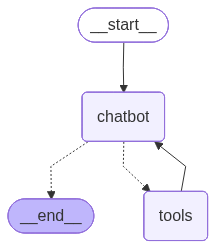

In [12]:
# 그래프 흐름: START → chatbot → tools → chatbot → ... → END
# chatbot 노드: LLM이 사용자 메시지를 받아 응답 또는 도구 호출을 결정해요
# tools 노드: tool_call이 있으면 도구를 실행해요
# 조건부 엣지: tool_call 유무에 따라 tools 또는 END로 분기해요
from IPython.display import Image, display

# ---------------------------------------------------
# 그래프 시각화: 챗봇 ↔ 도구 루프 구조 확인
# ---------------------------------------------------
display(Image(agent_graph.get_graph().draw_mermaid_png()))

In [13]:
# ---------------------------------------------------
# 에이전트 실행: 도구 호출이 필요한 질문
# ---------------------------------------------------
inputs = {"messages": [("user", "23과 47을 곱하면 얼마예요?")]}

# 질문: 23과 47을 곱하면 얼마예요?
# ==================================================

# stream_mode="updates": 각 노드가 반환한 업데이트 내용만 받아요
for chunk in agent_graph.stream(inputs, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()


--- 노드: chatbot ---
================================== Ai Message ==================================
Tool Calls:
  multiply (call_sgiW5dSLBOxIyLHeoyAeN8eh)
 Call ID: call_sgiW5dSLBOxIyLHeoyAeN8eh
  Args:
    a: 23
    b: 47

--- 노드: tools ---
================================= Tool Message =================================
Name: multiply

1081

--- 노드: chatbot ---
================================== Ai Message ==================================

23과 47을 곱하면 1081입니다.


In [14]:
# ---------------------------------------------------
# 에이전트 실행: 도구 호출이 필요 없는 질문 (바로 END로 이동)
# ---------------------------------------------------
inputs_no_tool = {"messages": [("user", "파이썬이 뭔가요? 한 문장으로 설명해줘.")]}

# 질문: 파이썬이 뭔가요? 한 문장으로 설명해줘.
# ==================================================

for chunk in agent_graph.stream(inputs_no_tool, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()


--- 노드: chatbot ---
================================== Ai Message ==================================

파이썬은 간결하고 읽기 쉬운 문법을 가진 고급 프로그래밍 언어로, 다양한 용도로 사용됩니다.


## 5. ToolNode와 tools_condition (사전 구축 컴포넌트)

앞서 `BasicToolNode`와 `route_tools`를 직접 구현했어요. LangGraph는 이 두 가지를 사전 구축(pre-built) 컴포넌트로 제공해요. 실제 프로젝트에서는 이 컴포넌트를 사용하면 코드가 훨씬 간결해져요.

| 직접 구현 | 사전 구축 컴포넌트 | 차이 |
|-----------|------------------|------|
| `BasicToolNode` | `ToolNode` | 에러 처리, 병렬 실행, 상태 주입 등 고급 기능 |
| `route_tools()` | `tools_condition` | 동일한 로직, 이미 검증된 구현 |

> 🎯 **강의 포인트**: `ToolNode`와 `BasicToolNode`의 코드를 나란히 비교해서 보여주세요. 내부 로직은 거의 동일하지만, `ToolNode`에는 에러 처리, 병렬 도구 호출, `ToolRuntime` 상태 주입 등의 기능이 추가되어 있어요.

In [15]:
# LangGraph 사전 구축 컴포넌트 가져오기
from langgraph.prebuilt import ToolNode, tools_condition

# ---------------------------------------------------
# ToolNode: 사전 구축된 도구 실행 노드
# ---------------------------------------------------
# BasicToolNode와 동일한 역할이지만 에러 처리, 병렬 실행 등 고급 기능 포함
tool_node = ToolNode(tools)

# ToolNode 초기화 완료!
print(f"ToolNode 타입: {type(tool_node).__name__}")

ToolNode 타입: ToolNode


In [16]:
# ---------------------------------------------------
# ToolNode + tools_condition으로 간결하게 그래프 구성
# ---------------------------------------------------
graph_builder2 = StateGraph(State)

# 노드 추가
graph_builder2.add_node("chatbot", chatbot)      # 챗봇 노드 (동일)
graph_builder2.add_node("tools", tool_node)      # 사전 구축 ToolNode

# 기본 엣지
graph_builder2.add_edge(START, "chatbot")
graph_builder2.add_edge("tools", "chatbot")

# 조건부 엣지: tools_condition으로 더 간결하게!
# tools_condition은 마지막 AIMessage의 tool_calls 유무로 분기해요
graph_builder2.add_conditional_edges(
    "chatbot",
    tools_condition,  # 사전 구축 라우터 함수 (route_tools와 동일한 동작)
)

# 그래프 컴파일
agent_graph2 = graph_builder2.compile()

# ToolNode + tools_condition 그래프 구축 완료!

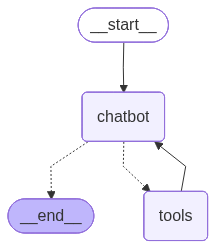

In [17]:
# 그래프 흐름: START → chatbot → tools → chatbot → ... → END
# chatbot 노드: LLM이 메시지를 처리하고 도구 호출 여부를 판단해요
# tools 노드: ToolNode가 도구를 자동 실행해요
# 조건부 엣지: tools_condition이 tool_call 유무로 분기해요
from IPython.display import Image, display
display(Image(agent_graph2.get_graph().draw_mermaid_png()))

In [18]:
# ---------------------------------------------------
# 사전 구축 컴포넌트 그래프 실행: 날씨 + 계산 복합 질문
# ---------------------------------------------------
inputs = {
    "messages": [
        ("user", "서울 날씨 알려줘. 그리고 기온에 2를 더하면 얼마야?")
    ]
}

# 질문: 서울 날씨 알려줘. 그리고 기온에 2를 더하면 얼마야?
# ==================================================

for chunk in agent_graph2.stream(inputs, stream_mode="updates"):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()


--- 노드: chatbot ---
================================== Ai Message ==================================
Tool Calls:
  get_weather (call_3JaJx7qD20rXBT03Wa2dvrjM)
 Call ID: call_3JaJx7qD20rXBT03Wa2dvrjM
  Args:
    city: 서울

--- 노드: tools ---
================================= Tool Message =================================
Name: get_weather

맑음, 기온 18°C, 습도 55%

--- 노드: chatbot ---
================================== Ai Message ==================================
Tool Calls:
  add (call_16S9HmH61PKSvHzpgTplEfxp)
 Call ID: call_16S9HmH61PKSvHzpgTplEfxp
  Args:
    a: 18
    b: 2

--- 노드: tools ---
================================= Tool Message =================================
Name: add

20

--- 노드: chatbot ---
================================== Ai Message ==================================

서울의 현재 날씨는 맑고, 기온은 18°C입니다. 기온에 2를 더하면 20°C입니다.


## 5-1. 실전 도구: TavilySearch로 웹 검색

지금까지 더미 도구(get_weather)로 도구 실행 흐름을 이해했어요. 이제 **실제로 웹 검색을 수행하는 도구**를 연결해볼게요.

`TavilySearch`는 AI 에이전트를 위해 최적화된 검색 API예요. LangChain V1에서는 `langchain-tavily` 패키지로 바로 사용할 수 있어요.

> 🔑 **핵심 개념**: 더미 도구와 실제 API 도구의 **그래프 구조는 완전히 동일**해요. `@tool` 데코레이터든 `TavilySearch`든 도구 인터페이스만 맞으면 `ToolNode`가 자동으로 실행해요. 이것이 LangGraph의 강력한 추상화예요.

> 💡 **실무 팁**: Tavily는 무료 티어(월 1,000건)를 제공해요. [tavily.com](https://tavily.com)에서 API 키를 발급받고 `.env` 파일에 `TAVILY_API_KEY=your_key`를 추가하세요.

In [19]:
# ---------------------------------------------------
# TavilySearch: AI 에이전트용 웹 검색 도구
# ---------------------------------------------------
# langchain-tavily 패키지에서 TavilySearch를 가져와요
from langchain_tavily import TavilySearch

# TavilySearch 인스턴스 생성
# max_results: 검색 결과 최대 개수
search_tool = TavilySearch(max_results=3)

# 실전 도구 목록: 계산 도구 + 실제 검색 도구
real_tools = [multiply, add, search_tool]

# 실전 도구 등록 완료!
for t in real_tools:
    print(f"  - {t.name}: {t.description[:60]}...")

  - multiply: 두 정수를 곱해서 반환해요.

곱셈 계산이 필요할 때 이 도구를 사용하세요....
  - add: 두 정수를 더해서 반환해요.

덧셈 계산이 필요할 때 이 도구를 사용하세요....
  - tavily_search: A search engine optimized for comprehensive, accurate, and t...


In [20]:
# ---------------------------------------------------
# 실전 에이전트: TavilySearch + 계산 도구
# ---------------------------------------------------
# 실제 검색 도구가 포함된 에이전트 그래프를 구성해요
real_llm = init_chat_model("openai:gpt-4o-mini")
real_llm_with_tools = real_llm.bind_tools(real_tools)


def real_chatbot(state: State) -> dict:
    """실전 도구가 연결된 챗봇 노드예요."""
    return {"messages": [real_llm_with_tools.invoke(state["messages"])]}


# 그래프 구성 (구조는 이전과 완전히 동일!)
real_builder = StateGraph(State)
real_builder.add_node("chatbot", real_chatbot)
real_builder.add_node("tools", ToolNode(real_tools))
real_builder.add_edge(START, "chatbot")
real_builder.add_edge("tools", "chatbot")
real_builder.add_conditional_edges("chatbot", tools_condition)
real_agent = real_builder.compile()

# 실제 웹 검색이 필요한 질문으로 테스트
# 질문: 2024년 노벨 물리학상 수상자가 누구예요?
# ==================================================

for chunk in real_agent.stream(
    {"messages": [("user", "2024년 노벨 물리학상 수상자가 누구예요?")]},
    stream_mode="updates",
):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()


--- 노드: chatbot ---
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_fACjZKPwAmeYRC1yFcZrWdfq)
 Call ID: call_fACjZKPwAmeYRC1yFcZrWdfq
  Args:
    query: 2024 Nobel Prize in Physics winner

--- 노드: tools ---
================================= Tool Message =================================
Name: tavily_search

{"query": "2024 Nobel Prize in Physics winner", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://sbmi.uth.edu/blog/2024/ai-wins-the-2024-nobel-prize-in-physics.htm", "title": "AI Wins the 2024 Nobel Prize in Physics", "content": "# AI Wins the 2024 Nobel Prize in Physics. **Infographic of The Nobel Prize in Physics 2024 showing image of John J. Hopfield from Princeton University, NJ and Geoffrey E. The 2024 Nobel Prize in Physics was awarded to two groundbreaking scientists whose early work laid the foundation for today’s advancements in artificial intelligence (AI) and machine

> 🎯 **강의 포인트**: 더미 도구(get_weather)로 만든 그래프와 실전 도구(TavilySearch)로 만든 그래프의 **코드 구조가 동일**하다는 점을 강조해주세요. 도구만 교체하면 동일한 에이전트 아키텍처로 실제 서비스를 만들 수 있어요.

## 6. 도구 에러 처리 (handle_tool_errors)

`ToolNode`는 도구 실행 중 발생하는 에러를 자동으로 처리할 수 있어요. 기본적으로 `handle_tool_errors=True`가 설정되어 있어서, 에러가 발생하면 `ToolMessage`에 에러 메시지를 담아 LLM에 전달해요.

> 💡 **실무 팁**: 에러를 그냥 발생시키는 것보다 `ToolMessage`로 포장해서 LLM에 전달하는 게 더 좋아요. LLM이 에러 내용을 보고 다른 접근법을 시도하거나, 사용자에게 친절한 에러 메시지를 전달할 수 있거든요.

### handle_tool_errors 옵션 정리

| 설정값 | 동작 |
|--------|------|
| `True` (기본값) | 모든 에러를 잡아 에러 메시지를 LLM에 전달 |
| `False` | 에러 처리 비활성화, 예외가 그대로 발생 |
| `"커스텀 메시지"` | 에러 발생 시 지정된 문자열을 LLM에 전달 |
| `callable` | 에러 객체를 받아 커스텀 메시지를 반환하는 함수 |
| `(ValueError, TypeError)` | 지정된 예외 타입만 처리 |

> ⚠️ **자주 하는 실수**: `handle_tool_errors=False`로 설정하면 도구 에러가 그래프 전체를 멈추게 해요. 프로덕션에서는 반드시 에러 처리를 활성화하세요.

> 💡 **실무 팁**: 커스텀 핸들러 함수를 사용하면 에러 유형별로 다른 안내 메시지를 LLM에 전달할 수 있어요. LLM은 이 메시지를 보고 "다른 파라미터로 재시도"하거나 "사용자에게 입력값 수정 요청"처럼 스스로 복구 전략을 세울 수 있어요.

In [21]:
from langgraph.graph import MessagesState


# ---------------------------------------------------
# 에러를 발생시키는 테스트 도구 정의
# ---------------------------------------------------
@tool
def divide(a: int, b: int) -> float:
    """두 정수를 나눠서 결과를 반환해요. 0으로 나누면 에러가 발생해요."""
    if b == 0:
        # 0으로 나누기 시도 시 에러 발생
        raise ValueError("0으로 나눌 수 없어요!")
    return a / b


# 커스텀 에러 핸들러 함수
def my_error_handler(error: Exception) -> str:
    """에러 타입에 따라 다른 안내 메시지를 반환하는 핸들러예요."""
    if isinstance(error, ValueError):
        return f"입력값 오류가 발생했어요: {error}. 다른 값을 시도해보세요."
    return f"예상치 못한 오류: {error}"


# ---------------------------------------------------
# 에러 처리 옵션별 ToolNode 생성
# ---------------------------------------------------
# 방법 1: 기본 에러 처리 (True)
tool_node_default = ToolNode([divide], handle_tool_errors=True)

# 방법 2: 커스텀 문자열 메시지
tool_node_custom_msg = ToolNode(
    [divide],
    handle_tool_errors="도구 실행 중 문제가 발생했어요. 다른 접근법을 시도해주세요.",
)

# 방법 3: 커스텀 핸들러 함수
tool_node_handler = ToolNode([divide], handle_tool_errors=my_error_handler)

# 에러 처리 옵션별 ToolNode 생성 완료!

In [22]:
# ---------------------------------------------------
# 에러 처리 동작 테스트: 0으로 나누기
# ---------------------------------------------------
# 에러를 유발하는 도구 호출 메시지 수동 생성
error_message = AIMessage(
    content="",
    tool_calls=[
        {
            "name": "divide",
            "args": {"a": 10, "b": 0},  # 0으로 나누기 → ValueError 발생
            "id": "error_test_001",
            "type": "tool_call",
        }
    ],
)

# 테스트 그래프 생성 (커스텀 핸들러 버전)
error_test_builder = StateGraph(MessagesState)
error_test_builder.add_node("tools", tool_node_handler)  # 커스텀 핸들러 사용
error_test_builder.add_edge(START, "tools")
error_test_builder.add_edge("tools", END)
error_test_app = error_test_builder.compile()

# 에러 처리 결과 확인
# === 에러 처리 결과 (커스텀 핸들러) ===
result = error_test_app.invoke({"messages": [error_message]})
last_msg = result["messages"][-1]
print(f"메시지 타입: {type(last_msg).__name__}")
print(f"상태: {last_msg.status}")
print(f"내용: {last_msg.content}")

메시지 타입: ToolMessage
상태: error
내용: 입력값 오류가 발생했어요: 0으로 나눌 수 없어요!. 다른 값을 시도해보세요.


## 7. 병렬 도구 호출

`ToolNode`는 여러 도구를 동시에 호출하는 **병렬 도구 호출**도 지원해요. AIMessage의 `tool_calls` 리스트에 여러 도구를 담으면, `ToolNode`가 모두 실행하고 각각의 `ToolMessage`를 반환해요.

> 🎯 **강의 포인트**: 병렬 도구 호출이 언제 유용한지 설명해주세요. 예를 들어 "서울과 부산의 날씨를 동시에 알려줘"라는 질문에서 두 번의 `get_weather` 호출을 순서가 아닌 동시에 처리할 수 있어요.

In [23]:
# ---------------------------------------------------
# 병렬 도구 호출 테스트
# ---------------------------------------------------
# 두 개의 도구를 동시에 호출하는 AIMessage 생성
parallel_message = AIMessage(
    content="",
    tool_calls=[
        {
            "name": "get_weather",
            "args": {"city": "서울"},     # 첫 번째 도구 호출
            "id": "parallel_001",
            "type": "tool_call",
        },
        {
            "name": "multiply",
            "args": {"a": 7, "b": 9},    # 두 번째 도구 호출 (동시에 실행)
            "id": "parallel_002",
            "type": "tool_call",
        },
    ],
)

# 병렬 실행용 테스트 그래프 생성
parallel_builder = StateGraph(MessagesState)
parallel_builder.add_node("tools", ToolNode(tools))
parallel_builder.add_edge(START, "tools")
parallel_builder.add_edge("tools", END)
parallel_app = parallel_builder.compile()

# 병렬 도구 호출 실행
# === 병렬 도구 호출 결과 ===
parallel_result = parallel_app.invoke({"messages": [parallel_message]})

# 원래 AIMessage는 제외하고 ToolMessage만 출력
for msg in parallel_result["messages"][1:]:
    print(f"\n도구: {msg.name}")
    print(f"결과: {msg.content}")


도구: get_weather
결과: 맑음, 기온 18°C, 습도 55%

도구: multiply
결과: 63


## 8. ToolRuntime으로 그래프 상태 접근하기

도구 실행 중에 그래프의 현재 상태에 접근해야 하는 경우가 있어요. 예를 들어, 현재까지의 대화 메시지 수를 확인하거나 사용자 설정 값을 참조할 때예요.

`ToolRuntime`을 도구의 매개변수로 선언하면, `ToolNode`가 자동으로 현재 상태를 주입해줘요. **LLM에게는 이 매개변수가 노출되지 않으므로** 도구 호출 방식에 영향을 주지 않아요.

> ⚠️ **자주 하는 실수**: `ToolRuntime`은 반드시 파라미터 타입 힌트로 선언해야 해요. `runtime: ToolRuntime`처럼 선언하면 `ToolNode`가 인식해서 상태를 자동 주입해줘요.

In [24]:
from langchain.tools import ToolRuntime


# ---------------------------------------------------
# ToolRuntime을 사용한 상태 접근 도구
# ---------------------------------------------------
@tool
def get_conversation_info(runtime: ToolRuntime) -> str:
    """현재 대화 세션의 메시지 수와 첫 번째 메시지 정보를 반환해요.

    ToolRuntime을 통해 그래프 상태에 접근해요.
    LLM에게는 이 파라미터가 보이지 않아요.
    """
    # runtime.state: 현재 그래프 상태에 접근
    messages = runtime.state["messages"]
    msg_count = len(messages)

    # 첫 번째 메시지 내용 가져오기 (있는 경우)
    first_msg_content = messages[0].content[:50] if messages else "없음"

    return (
        f"현재 대화에 총 {msg_count}개의 메시지가 있어요. "
        f"첫 번째 메시지: '{first_msg_content}...'"
    )


# ToolRuntime 사용 도구로 ToolNode 생성
state_aware_tool_node = ToolNode([get_conversation_info])

# ToolRuntime 도구 정의 완료!

In [25]:
from langchain.messages import HumanMessage, AIMessage

# ---------------------------------------------------
# ToolRuntime 상태 주입 테스트
# ---------------------------------------------------
# 여러 메시지가 있는 상태 시뮬레이션
test_messages = [
    HumanMessage(content="안녕하세요! 오늘 날씨 어때요?"),
    AIMessage(content="안녕하세요! 날씨 정보를 확인해드릴게요."),
    HumanMessage(content="지금 대화 몇 번째야?"),
    AIMessage(
        content="",
        tool_calls=[
            {
                "name": "get_conversation_info",
                "args": {},                        # ToolRuntime은 args가 비어있어도 돼요
                "id": "runtime_test_001",
                "type": "tool_call",
            }
        ],
    ),
]

# 테스트 그래프 생성 및 실행
runtime_test_builder = StateGraph(MessagesState)
runtime_test_builder.add_node("tools", state_aware_tool_node)
runtime_test_builder.add_edge(START, "tools")
runtime_test_builder.add_edge("tools", END)
runtime_test_app = runtime_test_builder.compile()

# === ToolRuntime 상태 주입 결과 ===
result = runtime_test_app.invoke({"messages": test_messages})
# 마지막 ToolMessage 출력
result["messages"][-1].pretty_print()

================================= Tool Message =================================
Name: get_conversation_info

현재 대화에 총 4개의 메시지가 있어요. 첫 번째 메시지: '안녕하세요! 오늘 날씨 어때요?...'


## 9. 실습: 나만의 도구를 만들어서 에이전트에 연결하기

지금까지 배운 내용을 바탕으로 나만의 도구를 만들고, 에이전트 그래프에 연결해보세요.

> 🎯 **강의 포인트**: 학생들이 직접 도구를 설계하는 경험이 중요해요. "어떤 기능을 도구로 만들 수 있을까?"를 생각하게 하는 게 좋아요. 텍스트 처리, 날짜 계산, 단위 변환 등 다양한 아이디어를 제안해보세요.

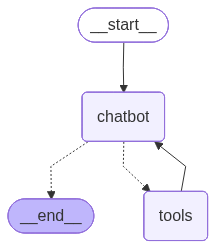

질문: 25도씨는 화씨로 얼마예요? 그리고 'LangGraph'의 글자 수와 5 곱하기 8도 알려주세요.

--- 노드: chatbot ---
================================== Ai Message ==================================
Tool Calls:
  celsius_to_fahrenheit (call_gKjR3zm5Z2JoFFUdVCI4jAj3)
 Call ID: call_gKjR3zm5Z2JoFFUdVCI4jAj3
  Args:
    celsius: 25
  text_length (call_FvEcGWWfilgnWvHY0XGp4WMF)
 Call ID: call_FvEcGWWfilgnWvHY0XGp4WMF
  Args:
    text: LangGraph
  multiply (call_T0JhiffOc0iNSXtenmq5bstk)
 Call ID: call_T0JhiffOc0iNSXtenmq5bstk
  Args:
    a: 5
    b: 8

--- 노드: tools ---
================================= Tool Message =================================
Name: celsius_to_fahrenheit

25.0°C = 77.0°F
================================= Tool Message =================================
Name: text_length

'LangGraph'의 글자 수는 9자입니다.
================================= Tool Message =================================
Name: multiply

40

--- 노드: chatbot ---
================================== Ai Message ==================================

25도씨는 화씨로 

In [26]:
from langchain.tools import tool
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from typing import Annotated, TypedDict
from IPython.display import Image, display


# ============================================================
# 구현 예시: 커스텀 도구 2개 정의
# ============================================================
@tool
def celsius_to_fahrenheit(celsius: float) -> str:
    """섭씨 온도를 화씨 온도로 변환해요.

    섭씨에서 화씨로 변환이 필요할 때 이 도구를 사용하세요.
    Args:
        celsius: 변환할 섭씨 온도값
    """
    fahrenheit = celsius * 9 / 5 + 32
    return f"{celsius}°C = {fahrenheit:.1f}°F"


@tool
def text_length(text: str) -> str:
    """텍스트의 글자 수를 계산해요.

    문자열 길이, 글자 수, 문자 수를 물어볼 때 이 도구를 사용하세요.
    Args:
        text: 길이를 계산할 텍스트
    """
    return f"'{text}'의 글자 수는 {len(text)}자입니다."


# ---------------------------------------------------
# 실습 도구들로 에이전트 그래프 구성
# ---------------------------------------------------
class PracticeState(TypedDict):
    messages: Annotated[list, add_messages]


practice_tools = [multiply, add, celsius_to_fahrenheit, text_length]

practice_llm = init_chat_model("openai:gpt-4o-mini")
practice_llm_with_tools = practice_llm.bind_tools(practice_tools)


def practice_chatbot(state: PracticeState):
    """실습용 챗봇 노드예요."""
    return {"messages": [practice_llm_with_tools.invoke(state["messages"])]}


practice_builder = StateGraph(PracticeState)
practice_builder.add_node("chatbot", practice_chatbot)
practice_builder.add_node("tools", ToolNode(practice_tools))
practice_builder.add_edge(START, "chatbot")
practice_builder.add_edge("tools", "chatbot")
practice_builder.add_conditional_edges("chatbot", tools_condition)
practice_graph = practice_builder.compile()

# 그래프 흐름: START → chatbot → tools → chatbot → ... → END
display(Image(practice_graph.get_graph().draw_mermaid_png()))

test_question = "25도씨는 화씨로 얼마예요? 그리고 'LangGraph'의 글자 수와 5 곱하기 8도 알려주세요."

print(f"질문: {test_question}")
for chunk in practice_graph.stream(
    {"messages": [("user", test_question)]},
    stream_mode="updates",
):
    for node_name, node_output in chunk.items():
        print(f"\n--- 노드: {node_name} ---")
        if "messages" in node_output:
            for msg in node_output["messages"]:
                msg.pretty_print()


## 핵심 요약

이 노트북에서 다음 내용을 배웠어요:

- **@tool 데코레이터**: Python 함수를 LLM이 호출 가능한 도구로 변환해요. docstring이 LLM의 도구 선택 가이드가 되므로 명확하게 작성하는 게 중요해요
- **bind_tools()**: LLM에 사용 가능한 도구를 등록해요. 바인딩된 LLM은 `tool_calls`가 담긴 AIMessage를 반환할 수 있어요
- **BasicToolNode vs ToolNode**: `BasicToolNode`를 직접 구현해서 도구 실행 원리를 이해했어요. 실제로는 `ToolNode`를 사용하면 에러 처리, 병렬 실행 등 고급 기능을 쉽게 활용할 수 있어요
- **tools_condition**: `AIMessage`에 `tool_calls`가 있으면 `"tools"`, 없으면 `END`를 반환하는 사전 구축 라우터 함수예요
- **add_conditional_edges**: 조건 함수 결과에 따라 분기하는 엣지를 추가해요. `chatbot ↔ tools` 루프를 형성하는 핵심이에요
- **handle_tool_errors**: `ToolNode`의 에러 처리 옵션으로, `True`/`False`/문자열/함수 등 다양한 방식으로 에러를 핸들링할 수 있어요
- **ToolRuntime**: 도구 파라미터로 선언하면 `ToolNode`가 현재 그래프 상태를 자동으로 주입해줘요. LLM에게는 노출되지 않아요

## 다음 노트북 예고

다음 `07-Memory-Checkpointer.ipynb`에서는 **InMemorySaver와 thread_id**를 배워요.

지금까지 만든 에이전트는 실행이 끝나면 대화 내용을 기억하지 못했어요. 다음 노트북에서는 `InMemorySaver`로 체크포인트를 설정하고 `thread_id`로 대화 세션을 구분해서, 이전 대화를 기억하는 **메모리가 있는 에이전트**를 만들어볼 거예요!